In [22]:
#Data Loading
!git clone https://github.com/HeYantong/MSSP6070-Yantong.git
%cd /content/MSSP6070-Yantong

!ls

Cloning into 'MSSP6070-Yantong'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 80 (delta 32), reused 6 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 3.25 MiB | 9.60 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/MSSP6070-Yantong
Adding_File_Structure.py  data		    README.md
Assignments		  MSSP6070-Yantong  WeeklyModules


In [23]:
import pandas as pd

df = pd.read_excel(
    "data/data_academic_performance.xlsx",
    sheet_name="SABER11_SABERPRO"
)

In [24]:
df.head()

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


In [25]:
# Data Preprocessing
# Initial Data Quality Check
df.shape

(12411, 45)

In [26]:
df.info()
df = df.drop(columns=["Unnamed: 9"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12411 entries, 0 to 12410
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   COD_S11           12411 non-null  object 
 1   GENDER            12411 non-null  object 
 2   EDU_FATHER        12411 non-null  object 
 3   EDU_MOTHER        12411 non-null  object 
 4   OCC_FATHER        12411 non-null  object 
 5   OCC_MOTHER        12411 non-null  object 
 6   STRATUM           12411 non-null  object 
 7   SISBEN            12411 non-null  object 
 8   PEOPLE_HOUSE      12411 non-null  object 
 9   Unnamed: 9        0 non-null      float64
 10  INTERNET          12411 non-null  object 
 11  TV                12411 non-null  object 
 12  COMPUTER          12411 non-null  object 
 13  WASHING_MCH       12411 non-null  object 
 14  MIC_OVEN          12411 non-null  object 
 15  CAR               12411 non-null  object 
 16  DVD               12411 non-null  object

In [27]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

,0


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
#Categorical Variables Check and Clean:
#Mother Education Level
import numpy as np

df["EDU_MOTHER"] = df["EDU_MOTHER"].replace({
    0: np.nan,
    "Not sure": np.nan,
    "Ninguno": "No education"
})

df["EDU_MOTHER"] = df["EDU_MOTHER"].str.strip()

df["EDU_MOTHER"].value_counts(dropna=False)

,count
EDU_MOTHER,
Complete Secundary,3106
Complete professional education,3059
Complete technique or technology,1495
Incomplete Secundary,1056
Postgraduate education,997
Complete primary,713
NaN,567
Incomplete primary,541
Incomplete Professional Education,502


In [30]:
#Father Education Level
df["EDU_FATHER"] = df["EDU_FATHER"].replace({
    0: np.nan,
    "Not sure": np.nan,
    "Ninguno": "No education"
})

df["EDU_FATHER"] = df["EDU_FATHER"].str.strip()

df["EDU_FATHER"].value_counts(dropna=False)

,count
EDU_FATHER,
Complete professional education,3016
Complete Secundary,2843
Complete technique or technology,1194
Incomplete Secundary,1091
Postgraduate education,1085
Complete primary,824
NaN,798
Incomplete primary,735
Incomplete Professional Education,425


In [31]:
#Stratum
df["STRATUM"] = df["STRATUM"].replace(0, np.nan)

df["STRATUM"].value_counts(dropna=False)

,count
STRATUM,
Stratum 3,4045
Stratum 2,4029
Stratum 1,1709
Stratum 4,1578
Stratum 5,633
Stratum 6,403
NaN,14


In [32]:
#Gender
df["GENDER"].value_counts(dropna=False)

,count
GENDER,
M,7368
F,5043


In [33]:
#Data Validity Check and Descriptive statistics:
score_columns = [
    "MAT_S11", "CR_S11", "ENG_S11",
    "QR_PRO", "CR_PRO", "ENG_PRO", "G_SC"
]

df[score_columns].describe().round(0).astype(int)

,MAT_S11,CR_S11,ENG_S11,QR_PRO,CR_PRO,ENG_PRO,G_SC
count,12411,12411,12411,12411,12411,12411,12411
mean,64,61,62,77,62,67,163
std,12,10,14,23,28,25,23
min,26,24,26,1,1,1,37
25%,56,54,50,65,42,51,147
50%,64,61,59,85,67,74,163
75%,72,67,72,96,86,88,179
max,100,100,100,100,100,100,247


In [34]:
df["S11_AVG"] = df[
    ["MAT_S11", "CR_S11", "CC_S11", "BIO_S11", "ENG_S11"]
].mean(axis=1).round(2)

df["S11_AVG_Z"] = (
    df["S11_AVG"] - df["S11_AVG"].mean()
) / df["S11_AVG"].std()

df["G_SC_Z"] = (
    df["G_SC"] - df["G_SC"].mean()
) / df["G_SC"].std()

df["ACADEMIC_CHANGE_Z"] = (
    df["G_SC_Z"] - df["S11_AVG_Z"]
)

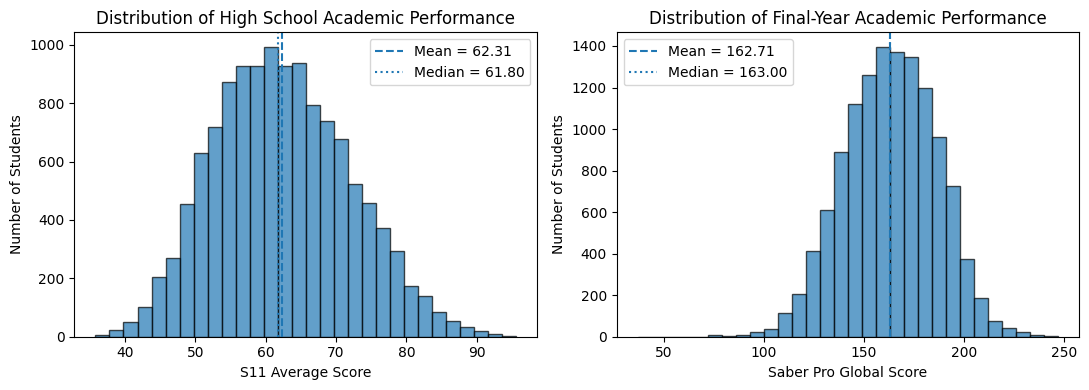

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# High school performance
axes[0].hist(df["S11_AVG"], bins=30, edgecolor="black", alpha=0.7)
axes[0].axvline(
    df["S11_AVG"].mean(),
    linestyle="--",
    label=f'Mean = {df["S11_AVG"].mean():.2f}'
)
axes[0].axvline(
    df["S11_AVG"].median(),
    linestyle=":",
    label=f'Median = {df["S11_AVG"].median():.2f}'
)
axes[0].set_title("Distribution of High School Academic Performance")
axes[0].set_xlabel("S11 Average Score")
axes[0].set_ylabel("Number of Students")
axes[0].legend()

# Final-year performance
axes[1].hist(df["G_SC"], bins=30, edgecolor="black", alpha=0.7)
axes[1].axvline(
    df["G_SC"].mean(),
    linestyle="--",
    label=f'Mean = {df["G_SC"].mean():.2f}'
)
axes[1].axvline(
    df["G_SC"].median(),
    linestyle=":",
    label=f'Median = {df["G_SC"].median():.2f}'
)
axes[1].set_title("Distribution of Final-Year Academic Performance")
axes[1].set_xlabel("Saber Pro Global Score")
axes[1].set_ylabel("Number of Students")
axes[1].legend()

plt.tight_layout()
plt.show()



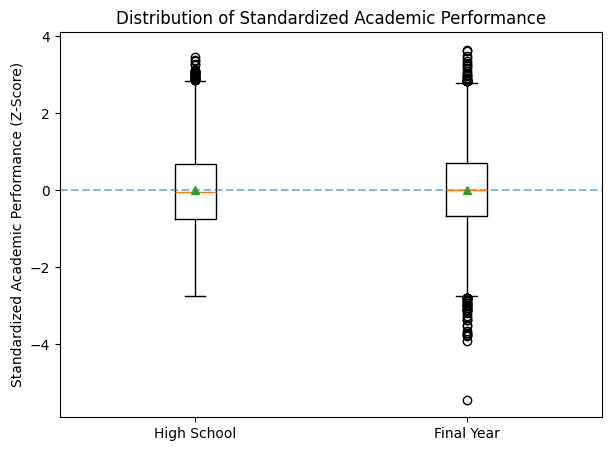

In [36]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df["S11_AVG_Z"].dropna(),
        df["G_SC_Z"].dropna()
    ],
    tick_labels=[
        "High School",
        "Final Year"
    ],
    showmeans=True
)

plt.ylabel("Standardized Academic Performance (Z-Score)")
plt.title("Distribution of Standardized Academic Performance")
plt.axhline(0, linestyle="--", alpha=0.5)

plt.show()

In [37]:
mother_summary = pd.DataFrame({
    "Count": df["EDU_MOTHER"].value_counts(dropna=False),
    "Percentage": df["EDU_MOTHER"].value_counts(
        dropna=False,
        normalize=True
    ) * 100
})

mother_summary["Percentage"] = mother_summary["Percentage"].round(2)

mother_summary

,Count,Percentage
EDU_MOTHER,,
Complete Secundary,3106,25.03
Complete professional education,3059,24.65
Complete technique or technology,1495,12.05
Incomplete Secundary,1056,8.51
Postgraduate education,997,8.03
Complete primary,713,5.74
NaN,567,4.57
Incomplete primary,541,4.36
Incomplete Professional Education,502,4.04


In [38]:
father_summary = pd.DataFrame({
    "Count": df["EDU_FATHER"].value_counts(dropna=False),
    "Percentage": df["EDU_FATHER"].value_counts(
        dropna=False,
        normalize=True
    ) * 100
})

father_summary["Percentage"] = father_summary["Percentage"].round(2)

father_summary

,Count,Percentage
EDU_FATHER,,
Complete professional education,3016,24.30
Complete Secundary,2843,22.91
Complete technique or technology,1194,9.62
Incomplete Secundary,1091,8.79
Postgraduate education,1085,8.74
Complete primary,824,6.64
NaN,798,6.43
Incomplete primary,735,5.92
Incomplete Professional Education,425,3.42


In [39]:
stratum_summary = pd.DataFrame({
    "Count": df["STRATUM"].value_counts(dropna=False),
    "Percentage": df["STRATUM"].value_counts(
        dropna=False,
        normalize=True
    ) * 100
})

stratum_summary["Percentage"] = stratum_summary["Percentage"].round(2)

stratum_summary

,Count,Percentage
STRATUM,,
Stratum 3,4045,32.59
Stratum 2,4029,32.46
Stratum 1,1709,13.77
Stratum 4,1578,12.71
Stratum 5,633,5.10
Stratum 6,403,3.25
NaN,14,0.11


In [40]:
gender_summary = pd.DataFrame({
    "Count": df["GENDER"].value_counts(dropna=False),
    "Percentage": df["GENDER"].value_counts(
        dropna=False,
        normalize=True
    ) * 100
})

gender_summary["Percentage"] = gender_summary["Percentage"].round(2)

gender_summary

,Count,Percentage
GENDER,,
M,7368,59.37
F,5043,40.63


In [41]:
# Parent's Educational Background
# Is parental educational attainment associated with students' academic performance?
education_map = {
    "No education": 0,
    "Incomplete primary": 1,
    "Complete primary": 2,
    "Incomplete Secundary": 3,
    "Complete Secundary": 4,
    "Incomplete technical or technological": 5,
    "Complete technique or technology": 6,
    "Incomplete Professional Education": 7,
    "Complete professional education": 8,
    "Postgraduate education": 9
}

df["MOTHER_EDU_LEVEL"] = df["EDU_MOTHER"].map(education_map)
df["FATHER_EDU_LEVEL"] = df["EDU_FATHER"].map(education_map)

df["PARENT_EDU_LEVEL"] = df[
    ["MOTHER_EDU_LEVEL", "FATHER_EDU_LEVEL"]
].max(axis=1)

# PARENT_EDU was created by taking the higher education level between the student's mother and father to represent overall parental educational background.

education_labels = {v: k for k, v in education_map.items()}

df["PARENT_EDU"] = df["PARENT_EDU_LEVEL"].map(education_labels)

df["PARENT_EDU"].value_counts()

# Order parental education from highest to lowest
education_order = list(education_map.keys())[::-1]

df["PARENT_EDU"].value_counts()

,count
PARENT_EDU,
Complete professional education,3832
Complete Secundary,2702
Postgraduate education,1586
Complete technique or technology,1387
Incomplete Secundary,788
Complete primary,526
Incomplete Professional Education,452
Incomplete primary,372
Incomplete technical or technological,301


In [42]:
df["S11_AVG"] = df[
    ["MAT_S11", "CR_S11", "CC_S11", "BIO_S11", "ENG_S11"]
].mean(axis=1).round(2)

# S11_AVG was calculated as the average of the five S11 subject scores to represent overall high school academic performance.

parent_performance_s11 = df.groupby("PARENT_EDU").agg(
    Count=("S11_AVG", "count"),
    Mean_Overall=("S11_AVG", "mean"),
    Mean_Math=("MAT_S11", "mean"),
    Mean_Reading=("CR_S11", "mean"),
    Mean_Citizenship=("CC_S11", "mean"),
    Mean_Biology=("BIO_S11", "mean"),
    Mean_English=("ENG_S11", "mean")
).round(2)

parent_performance_s11 = parent_performance_s11.reindex(education_order)

parent_performance_s11

,Count,Mean_Overall,Mean_Math,Mean_Reading,Mean_Citizenship,Mean_Biology,Mean_English
PARENT_EDU,,,,,,,
Postgraduate education,1586,68.49,70.85,65.17,64.87,69.60,71.95
Complete professional education,3832,64.15,66.18,61.99,61.82,65.44,65.34
Incomplete Professional Education,452,63.07,64.50,61.92,61.59,64.29,63.03
Complete technique or technology,1387,61.52,63.55,60.36,60.39,63.13,60.16
Incomplete technical or technological,301,61.40,63.18,60.96,60.19,63.36,59.31
Complete Secundary,2702,59.57,61.63,58.89,58.87,61.71,56.72
Incomplete Secundary,788,58.63,60.40,58.07,58.52,60.37,55.78
Complete primary,526,58.10,60.25,57.37,57.97,60.48,54.42
Incomplete primary,372,58.55,60.46,58.12,58.02,60.99,55.17


In [43]:
parent_pro_performance = df.groupby("PARENT_EDU").agg(
    Count=("G_SC", "count"),
    Mean_Global_Score=("G_SC", "mean"),
    Mean_Percentile=("PERCENTILE", "mean")
).round(2)

parent_pro_performance = parent_pro_performance.reindex(education_order)

parent_pro_performance

,Count,Mean_Global_Score,Mean_Percentile
PARENT_EDU,,,
Postgraduate education,1586,175.25,80.88
Complete professional education,3832,166.33,72.32
Incomplete Professional Education,452,164.08,70.89
Complete technique or technology,1387,161.22,67.21
Incomplete technical or technological,301,160.66,67.22
Complete Secundary,2702,157.21,62.70
Incomplete Secundary,788,155.20,60.39
Complete primary,526,154.79,59.74
Incomplete primary,372,154.23,59.35


In [44]:
# standardized trajectory analysis:
df["S11_AVG_Z"] = (
    (df["S11_AVG"] - df["S11_AVG"].mean())
    / df["S11_AVG"].std()
)

df["G_SC_Z"] = (
    (df["G_SC"] - df["G_SC"].mean())
    / df["G_SC"].std()
)

df["ACADEMIC_CHANGE_Z"] = df["G_SC_Z"] - df["S11_AVG_Z"]

parent_trajectory = df.groupby("PARENT_EDU").agg(
    Count=("PARENT_EDU", "size"),
    Mean_S11_Z=("S11_AVG_Z", "mean"),
    Mean_PRO_Z=("G_SC_Z", "mean"),
    Mean_Change_Z=("ACADEMIC_CHANGE_Z", "mean")
).round(2)

parent_trajectory = parent_trajectory.reindex(education_order)

parent_trajectory


,Count,Mean_S11_Z,Mean_PRO_Z,Mean_Change_Z
PARENT_EDU,,,,
Postgraduate education,1586,0.64,0.54,-0.10
Complete professional education,3832,0.19,0.16,-0.03
Incomplete Professional Education,452,0.08,0.06,-0.02
Complete technique or technology,1387,-0.08,-0.06,0.02
Incomplete technical or technological,301,-0.09,-0.09,0.01
Complete Secundary,2702,-0.28,-0.24,0.05
Incomplete Secundary,788,-0.38,-0.32,0.06
Complete primary,526,-0.44,-0.34,0.09
Incomplete primary,372,-0.39,-0.37,0.02


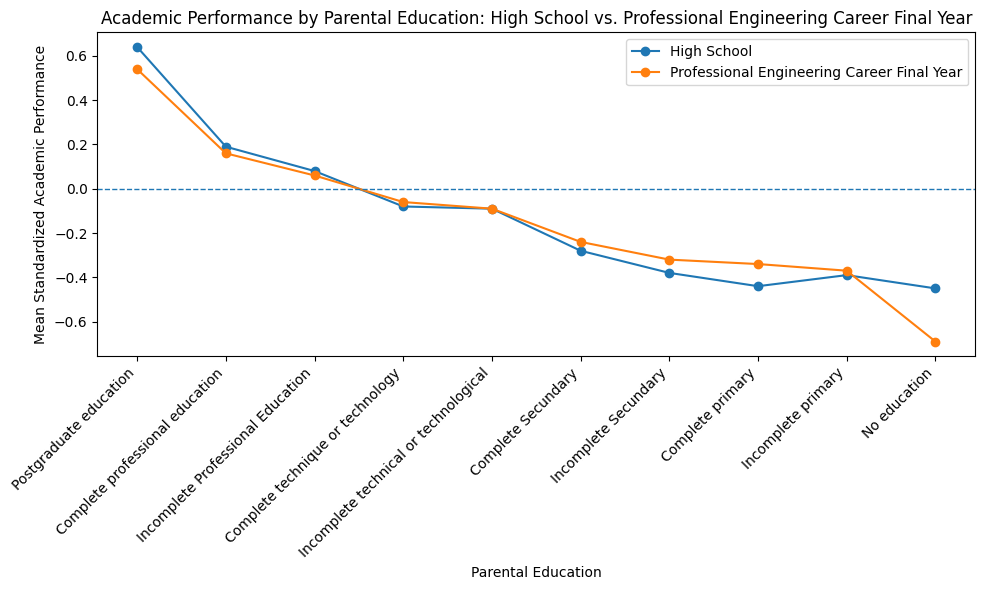

In [45]:
import matplotlib.pyplot as plt

plot_data = parent_trajectory.dropna()

plt.figure(figsize=(10, 6))

plt.plot(
    plot_data.index,
    plot_data["Mean_S11_Z"],
    marker="o",
    label="High School"
)

plt.plot(
    plot_data.index,
    plot_data["Mean_PRO_Z"],
    marker="o",
    label="Professional Engineering Career Final Year"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Parental Education")
plt.ylabel("Mean Standardized Academic Performance")
plt.title("Academic Performance by Parental Education: High School vs. Professional Engineering Career Final Year")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Socioeconomic Status
# Variable Selection:
df["SEL"].value_counts(dropna=False)

,count
SEL,
2,4742
4,4040
1,2138
3,1491


In [47]:
pd.crosstab(df["STRATUM"], df["SEL"])

SEL,1,2,3,4
STRATUM,,,,
Stratum 1,837,685,104,83
Stratum 2,923,2038,458,610
Stratum 3,326,1580,676,1463
Stratum 4,40,339,171,1028
Stratum 5,3,70,66,494
Stratum 6,6,24,13,360


In [48]:
sel_s11 = df.groupby("SEL").agg(
    Count=("S11_AVG", "count"),
    Mean_Overall=("S11_AVG", "mean"),
    Mean_Math=("MAT_S11", "mean"),
    Mean_Reading=("CR_S11", "mean"),
    Mean_Citizenship=("CC_S11", "mean"),
    Mean_Biology=("BIO_S11", "mean"),
    Mean_English=("ENG_S11", "mean")
).round(2)

sel_s11

,Count,Mean_Overall,Mean_Math,Mean_Reading,Mean_Citizenship,Mean_Biology,Mean_English
SEL,,,,,,,
1,2138,59.12,61.54,58.41,58.91,61.76,55.00
2,4742,60.42,62.36,59.70,59.45,62.31,58.26
3,1491,61.77,63.47,60.41,60.32,63.22,61.45
4,4040,66.42,68.41,63.43,63.27,67.30,69.69


In [49]:
sel_pro = df.groupby("SEL").agg(
    Count=("G_SC", "count"),
    Mean_Global_Score=("G_SC", "mean"),
    Mean_Percentile=("PERCENTILE", "mean")
).round(2)

sel_pro

,Count,Mean_Global_Score,Mean_Percentile
SEL,,,
1,2138,155.47,60.67
2,4742,158.54,64.27
3,1491,162.30,68.21
4,4040,171.58,77.55


In [50]:
sel_trajectory = df.groupby("SEL").agg(
    Count=("SEL", "size"),
    Mean_S11_Z=("S11_AVG_Z", "mean"),
    Mean_PRO_Z=("G_SC_Z", "mean"),
    Mean_Change_Z=("ACADEMIC_CHANGE_Z", "mean")
).round(2)

sel_trajectory

,Count,Mean_S11_Z,Mean_PRO_Z,Mean_Change_Z
SEL,,,,
1,2138,-0.33,-0.31,0.02
2,4742,-0.20,-0.18,0.02
3,1491,-0.06,-0.02,0.04
4,4040,0.43,0.38,-0.04


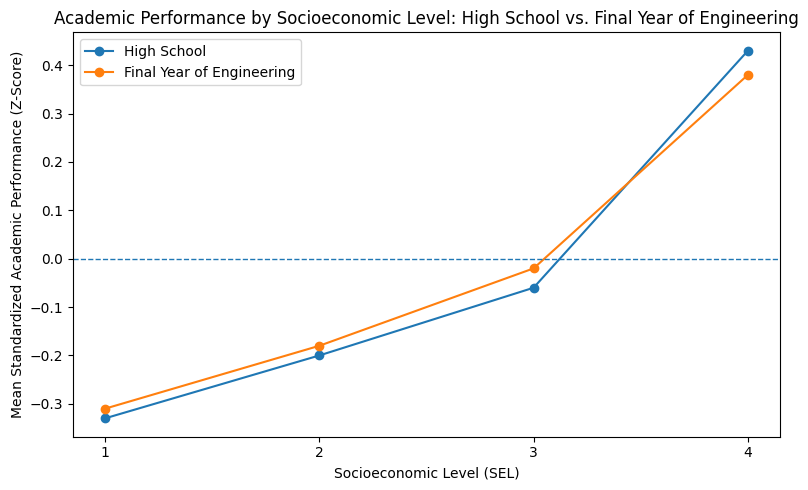

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    sel_trajectory.index,
    sel_trajectory["Mean_S11_Z"],
    marker="o",
    label="High School"
)

plt.plot(
    sel_trajectory.index,
    sel_trajectory["Mean_PRO_Z"],
    marker="o",
    label="Final Year of Engineering"
)

# Overall sample mean
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Socioeconomic Level (SEL)")
plt.ylabel("Mean Standardized Academic Performance (Z-Score)")
plt.title(
    "Academic Performance by Socioeconomic Level: "
    "High School vs. Final Year of Engineering"
)

plt.xticks([1, 2, 3, 4])
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
# Gender Differences
gender_s11 = df.groupby("GENDER").agg(
    Count=("S11_AVG", "count"),
    Mean_Overall=("S11_AVG", "mean"),
    Mean_Math=("MAT_S11", "mean"),
    Mean_Reading=("CR_S11", "mean"),
    Mean_Citizenship=("CC_S11", "mean"),
    Mean_Biology=("BIO_S11", "mean"),
    Mean_English=("ENG_S11", "mean")
).round(2)

gender_s11

,Count,Mean_Overall,Mean_Math,Mean_Reading,Mean_Citizenship,Mean_Biology,Mean_English
GENDER,,,,,,,
F,5043,61.3,61.93,60.9,59.96,62.27,61.45
M,7368,63.0,65.96,60.7,61.22,65.10,62.04


In [53]:
gender_pro = df.groupby("GENDER").agg(
    Count=("G_SC", "count"),
    Mean_Global_Score=("G_SC", "mean"),
    Mean_Percentile=("PERCENTILE", "mean"),
    Mean_Quantitative=("QR_PRO", "mean"),
    Mean_Reading=("CR_PRO", "mean"),
    Mean_Citizenship=("CC_PRO", "mean"),
    Mean_English=("ENG_PRO", "mean"),
    Mean_Writing=("WC_PRO", "mean"),
    Mean_Engineering=("FEP_PRO","mean")
).round(2)

gender_pro

,Count,Mean_Global_Score,Mean_Percentile,Mean_Quantitative,Mean_Reading,Mean_Citizenship,Mean_English,Mean_Writing,Mean_Engineering
GENDER,,,,,,,,,
F,5043,161.28,67.13,71.89,61.34,58.57,66.53,56.62,145.3
M,7368,163.69,69.35,81.20,62.79,59.61,68.16,51.71,145.6


In [54]:
gender_trajectory = df.groupby("GENDER").agg(
    Count=("GENDER", "size"),
    Mean_S11_Z=("S11_AVG_Z", "mean"),
    Mean_PRO_Z=("G_SC_Z", "mean"),
    Mean_Change_Z=("ACADEMIC_CHANGE_Z", "mean")
).round(2)

gender_trajectory

,Count,Mean_S11_Z,Mean_PRO_Z,Mean_Change_Z
GENDER,,,,
F,5043,-0.10,-0.06,0.04
M,7368,0.07,0.04,-0.03


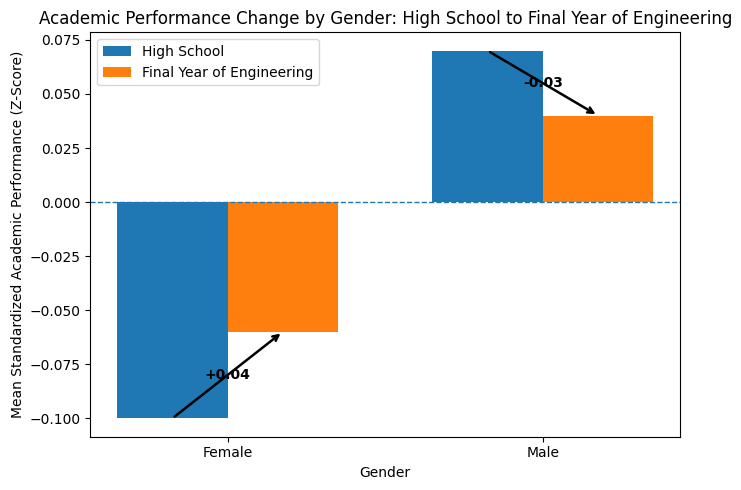

In [55]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(gender_trajectory.index))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

# High School
ax.bar(
    x - width/2,
    gender_trajectory["Mean_S11_Z"],
    width,
    label="High School"
)

# Final Year
ax.bar(
    x + width/2,
    gender_trajectory["Mean_PRO_Z"],
    width,
    label="Final Year of Engineering"
)

# Overall sample mean
ax.axhline(0, linestyle="--", linewidth=1)

# Add arrows to visualize change
for i in range(len(gender_trajectory)):

    start = gender_trajectory["Mean_S11_Z"].iloc[i]
    end = gender_trajectory["Mean_PRO_Z"].iloc[i]
    change = gender_trajectory["Mean_Change_Z"].iloc[i]

    # Arrow from High School to Final Year
    ax.annotate(
        "",
        xy=(x[i] + width/2, end),
        xytext=(x[i] - width/2, start),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.8
        )
    )

    # Change label
    ax.text(
        x[i],
        (start + end) / 2,
        f"{change:+.2f}",
        ha="center",
        va="center",
        fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(["Female", "Male"])

ax.set_xlabel("Gender")
ax.set_ylabel("Mean Standardized Academic Performance (Z-Score)")

ax.set_title(
    "Academic Performance Change by Gender: "
    "High School to Final Year of Engineering"
)

ax.legend()

plt.tight_layout()
plt.show()

In [56]:
# Digital Access & SEL
df[["INTERNET", "COMPUTER"]].value_counts(dropna=False)

INTERNET  COMPUTER
Yes       Yes         8917
No        No          1402
          Yes         1257
Yes       No           835
Name: count, dtype: int64

In [57]:
def digital_access(row):
    if row["INTERNET"] == "Yes" and row["COMPUTER"] == "Yes":
        return "Both"
    elif row["INTERNET"] == "Yes" and row["COMPUTER"] == "No":
        return "Internet Only"
    elif row["INTERNET"] == "No" and row["COMPUTER"] == "Yes":
        return "Computer Only"
    else:
        return "Neither"

df["DIGITAL_ACCESS"] = df.apply(digital_access, axis=1)

df["DIGITAL_ACCESS"].value_counts()

,count
DIGITAL_ACCESS,
Both,8917
Neither,1402
Computer Only,1257
Internet Only,835


In [58]:
# Do students with different levels of digital access show different academic performance and academic trajectories?

digital_distribution = pd.crosstab(
    df["SEL"],
    df["DIGITAL_ACCESS"],
    normalize="index"
).round(3) * 100

digital_distribution

DIGITAL_ACCESS,Both,Computer Only,Internet Only,Neither
SEL,,,,
1,39.6,18.5,9.3,32.6
2,69.1,12.2,7.7,11.0
3,81.1,7.3,6.0,5.6
4,88.7,4.3,4.5,2.5


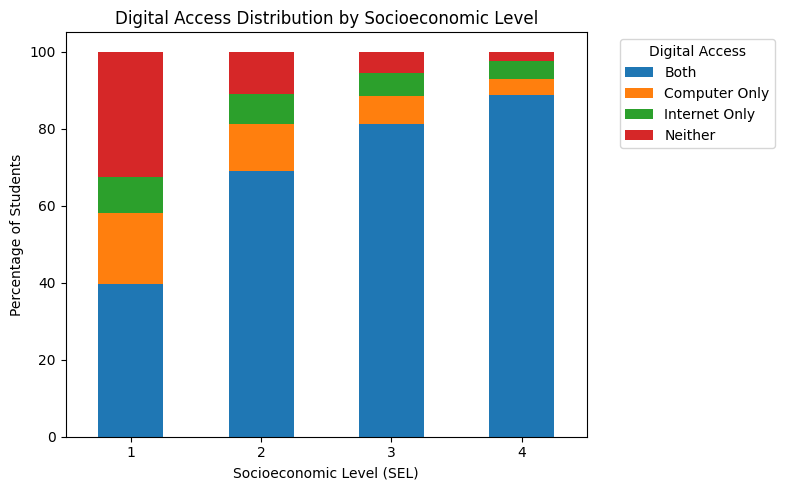

In [59]:
digital_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.xlabel("Socioeconomic Level (SEL)")
plt.ylabel("Percentage of Students")
plt.title("Digital Access Distribution by Socioeconomic Level")

plt.legend(
    title="Digital Access",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [60]:
digital_performance = df.groupby("DIGITAL_ACCESS").agg(
    Count=("G_SC", "count"),
    Mean_S11_Z=("S11_AVG_Z", "mean"),
    Mean_PRO_Z=("G_SC_Z", "mean"),
    Mean_Change_Z=("ACADEMIC_CHANGE_Z", "mean")
).round(2)

digital_performance

,Count,Mean_S11_Z,Mean_PRO_Z,Mean_Change_Z
DIGITAL_ACCESS,,,,
Both,8917,0.13,0.12,-0.01
Computer Only,1257,-0.32,-0.30,0.02
Internet Only,835,-0.18,-0.12,0.06
Neither,1402,-0.41,-0.40,0.02


In [61]:
digital_sel = df.groupby(
    ["SEL", "DIGITAL_ACCESS"]
).agg(
    Count=("G_SC", "count"),
    Mean_S11_Z=("S11_AVG_Z", "mean"),
    Mean_PRO_Z=("G_SC_Z", "mean"),
    Mean_Change_Z=("ACADEMIC_CHANGE_Z", "mean")
).round(2)

digital_sel

Count  Mean_S11_Z  Mean_PRO_Z  Mean_Change_Z
SEL DIGITAL_ACCESS                                              
1   Both              847       -0.25       -0.24           0.01
    Computer Only     396       -0.42       -0.40           0.02
    Internet Only     198       -0.21       -0.18           0.03
    Neither           697       -0.41       -0.40           0.02
2   Both             3276       -0.13       -0.11           0.02
    Computer Only     577       -0.35       -0.34           0.02
    Internet Only     367       -0.20       -0.15           0.05
    Neither           522       -0.44       -0.45          -0.02
3   Both             1209        0.00        0.03           0.03
    Computer Only     109       -0.30       -0.22           0.09
    Internet Only      89       -0.16       -0.11           0.05
    Neither            84       -0.44       -0.34           0.11
4   Both             3585        0.49        0.44          -0.06
    Computer Only     175       -0.00        0.01           0.01
    Internet Only     181       -0.12        0.01           0.13
    Neither            99       -0.26       -0.15           0.11

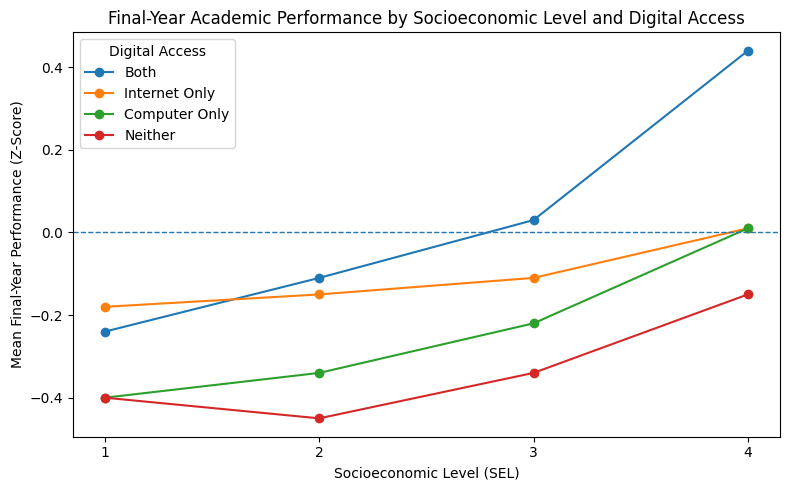

In [62]:
import matplotlib.pyplot as plt

plot_data = (
    digital_sel["Mean_PRO_Z"]
    .unstack("DIGITAL_ACCESS")
)

plot_data = plot_data[
    ["Both", "Internet Only", "Computer Only", "Neither"]
]

plt.figure(figsize=(8, 5))

for access in plot_data.columns:
    plt.plot(
        plot_data.index,
        plot_data[access],
        marker="o",
        label=access
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Socioeconomic Level (SEL)")
plt.ylabel("Mean Final-Year Performance (Z-Score)")
plt.title(
    "Final-Year Academic Performance by "
    "Socioeconomic Level and Digital Access"
)

plt.xticks([1, 2, 3, 4])
plt.legend(title="Digital Access")

plt.tight_layout()
plt.show()

In [63]:
# Final-year performance gap between Both and Neither
access_gap = (
    digital_sel["Mean_PRO_Z"]
    .unstack("DIGITAL_ACCESS")
)

access_gap["Both_vs_Neither_Gap"] = (
    access_gap["Both"] -
    access_gap["Neither"]
)

access_gap[["Both_vs_Neither_Gap"]].round(2)

DIGITAL_ACCESS,Both_vs_Neither_Gap
SEL,
1,0.16
2,0.34
3,0.37
4,0.59


In [64]:
# Final-year performance gap between Internet Only and Computer Only
partial_access_gap = (
    digital_sel["Mean_PRO_Z"]
    .unstack("DIGITAL_ACCESS")
)

partial_access_gap["Internet_vs_Computer_Gap"] = (
    partial_access_gap["Internet Only"] -
    partial_access_gap["Computer Only"]
)

partial_access_gap[["Internet_vs_Computer_Gap"]].round(2)

DIGITAL_ACCESS,Internet_vs_Computer_Gap
SEL,
1,0.22
2,0.19
3,0.11
4,0.00
